# Learning text watermarks: follow keyed token choices

Text watermarking becomes easier to understand once you stop looking for hidden characters. The signal is created while a model chooses ordinary tokens: a secret key labels plausible choices as **green** or **red**, and the sampler gives green choices a small probability advantage. The watermark is the pattern that accumulates across many decisions.

This notebook builds that mental model from one word choice to a statistical detector, then explores length, bias and paraphrase. The vocabulary is deliberately small so every intermediate step remains visible. It teaches the mechanism and its trade-offs; it does not reproduce a provider's model, key or calibrated detector.

## How to use this notebook

Run the cells from top to bottom. Each section adds one idea to the previous one: mapping, probability bias, position dependence, accumulation, calibration and attack.

By the end, you should be able to explain why:

- a watermark changes relative probabilities rather than adding hidden text;
- the same token can be green at one position and red at another;
- one green token is uninteresting but a long excess can become evidence;
- rewriting the passage can preserve meaning while destroying the keyed pattern.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    widgets = None
    HAS_WIDGETS = False

RUN_INTERACTIVE = HAS_WIDGETS and os.environ.get('WATERMARKS_INTERACTIVE', '1') != '0'
print(f'ipywidgets available: {HAS_WIDGETS}')


ipywidgets available: True


## 1. Begin with one token choice

Suppose the model has reached `The cat sat on the`. It considers several plausible next words. Before discussing a whole passage, inspect the smallest useful object: the mapping from candidate token to keyed color at one generation position.

The key does not decide the answer by itself. It supplies a green/red label that the sampler can use as a gentle preference.

In [2]:
KEY = 115

CONTEXTS = [
    ('The', ['cat', 'dog', 'fox'], [2.0, 1.6, 0.8]),
    ('The cat', ['sat', 'ran', 'slept'], [1.9, 1.5, 1.0]),
    ('The cat sat', ['on', 'near', 'beside'], [2.0, 1.2, 0.9]),
    ('The cat sat on', ['the'], [2.0]),
    ('The cat sat on the', ['mat', 'rug', 'sofa', 'floor'], [2.0, 1.5, 1.0, 0.8]),
]

VOCABULARY = np.array(sorted({
    token
    for _, candidates, _ in CONTEXTS
    for token in candidates
} | {'a', 'an', 'the', 'useful', 'small', 'large', 'model', 'image', 'video',
   'audio', 'text', 'signal', 'hidden', 'visible', 'robust', 'fragile',
   'detect', 'detector', 'create', 'edit', 'source', 'human', 'generated',
   'content', 'token', 'probability', 'secret', 'key', 'sample', 'transform',
   'compression', 'crop', 'noise', 'feline', 'automobile', 'car', 'vehicle'}))
VOCABULARY_INDEX = {token: index for index, token in enumerate(VOCABULARY)}

def green_mask(position, key=KEY, vocabulary_size=len(VOCABULARY)):
    local_rng = np.random.default_rng(int(key) + 10007 * int(position))
    permutation = local_rng.permutation(vocabulary_size)
    mask = np.zeros(vocabulary_size, dtype=bool)
    mask[permutation[:vocabulary_size // 2]] = True
    return mask

def mapping_for(position, candidates, key=KEY):
    mask = green_mask(position, key)
    return {token: bool(mask[VOCABULARY_INDEX[token]]) for token in candidates}

context, candidates, base_logits = CONTEXTS[-1]
mapping = mapping_for(len(CONTEXTS) - 1, candidates)
print(f'Context: {context} ___')
print('{:<12} {:<12}'.format('Candidate', 'Keyed color'))
print('-' * 24)
for token in candidates:
    print(f"{token:<12} {'green' if mapping[token] else 'red':<12}")


Context: The cat sat on the ___
Candidate    Keyed color 
------------------------
mat          red         
rug          green       
sofa         red         
floor        red         


## 2. Observe how a small bias changes probabilities

Move the context slider and compare the two bars for each candidate. The left bar is the toy model's original probability; the right bar includes the green-list bias.

The bias changes the distribution without forcing a word. A green candidate can still lose, and a red candidate can still win. This is the central quality trade-off: the signal must influence enough choices to become detectable without overwhelming what the language model would naturally say.

In [3]:
def softmax(values):
    values = np.asarray(values, dtype=float)
    probabilities = np.exp(values - values.max())
    return probabilities / probabilities.sum()

def plot_choice_step(context_index=4, bias=1.5, key=KEY):
    context, candidates, base_logits = CONTEXTS[int(context_index)]
    position = int(context_index)
    mapping = mapping_for(position, candidates, key)
    labels = ['green' if mapping[token] else 'red' for token in candidates]
    base_probabilities = softmax(base_logits)
    marked_logits = np.asarray(base_logits, dtype=float) + float(bias) * np.asarray([mapping[token] for token in candidates])
    marked_probabilities = softmax(marked_logits)
    colors = ['tab:green' if value == 'green' else 'tab:red' for value in labels]

    figure, axis = plt.subplots(figsize=(9, 4.2))
    x = np.arange(len(candidates))
    axis.bar(x - 0.19, base_probabilities, width=0.38, color='lightgray', label='model before watermark')
    axis.bar(x + 0.19, marked_probabilities, width=0.38, color=colors, label=f'after bias={float(bias):.2f}')
    axis.set_xticks(x, [f'{token} ({label})' for token, label in zip(candidates, labels)])
    axis.set_ylabel('probability')
    axis.set_ylim(0, max(base_probabilities.max(), marked_probabilities.max()) * 1.25)
    axis.set_title(f'Next-token choice after: {context}')
    axis.legend(loc='upper right')
    for index, probability in enumerate(marked_probabilities):
        axis.text(index + 0.19, probability + 0.01, f'{probability:.0%}', ha='center', fontsize=9)
    plt.tight_layout()

if RUN_INTERACTIVE:
    widgets.interact(
        plot_choice_step,
        context_index=widgets.IntSlider(value=4, min=0, max=len(CONTEXTS) - 1, step=1, description='context'),
        bias=widgets.FloatSlider(value=1.5, min=0, max=3, step=0.25, description='bias'),
    )
else:
    plot_choice_step()


interactive(children=(IntSlider(value=4, description='context', max=4), FloatSlider(value=1.5, description='bi…

## 3. See why key and position both matter

A token is not permanently green or red. Its label depends on both the secret key and the generation position. The grid makes that changing map visible across several tokens.

This prevents the watermark from collapsing into a fixed list of favored words. It also explains why the detector needs the correct key and the exact token sequence: it must reconstruct the same position-aware map before it can count evidence.

In [4]:
GRID_TOKENS = ['cat', 'dog', 'sat', 'ran', 'mat', 'rug', 'sofa', 'floor']

def plot_key_grid(key=KEY):
    values = np.asarray([[green_mask(position, int(key))[VOCABULARY_INDEX[token]]
                         for token in GRID_TOKENS]
                        for position in range(8)], dtype=int)
    figure, axis = plt.subplots(figsize=(10, 4.2))
    axis.imshow(values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    axis.set_xticks(range(len(GRID_TOKENS)), GRID_TOKENS, rotation=30, ha='right')
    axis.set_yticks(range(8), [f'position {position}' for position in range(8)])
    axis.set_title(f'Keyed green/red map for key={int(key)}')
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            axis.text(column, row, 'G' if values[row, column] else 'R', ha='center', va='center', color='black', fontweight='bold')
    axis.set_xlabel('candidate token')
    axis.set_ylabel('generation position')
    plt.tight_layout()

if RUN_INTERACTIVE:
    widgets.interact(plot_key_grid, key=widgets.IntSlider(value=KEY, min=1, max=999, step=1, description='secret key'))
else:
    plot_key_grid()


interactive(children=(IntSlider(value=115, description='secret key', max=999, min=1), Output()), _dom_classes=…

## 4. Build a pattern across a short completion

The next cell connects several choices into a short sentence and marks every selected green token with `*`. Comparing the unwatermarked and biased completions shows how small local preferences become a passage-level pattern.

To keep this first comparison unambiguous, the example chooses the highest-probability candidate at each step. The longer detector simulations return to stochastic sampling.

In [5]:
def choose_completion(bias=0.0, key=KEY):
    selected = []
    memberships = []
    for position, (context, candidates, base_logits) in enumerate(CONTEXTS):
        mapping = mapping_for(position, candidates, key)
        logits = np.asarray(base_logits, dtype=float) + float(bias) * np.asarray([mapping[token] for token in candidates])
        token = candidates[int(np.argmax(logits))]
        selected.append(token)
        memberships.append(mapping[token])
    return selected, memberships

def show_completion(bias, label):
    tokens, memberships = choose_completion(bias=bias)
    sentence = ' '.join(['The'] + tokens) + '.'
    print(f'{label:<20} {sentence}')
    print(f"{'green choices':<20} {sum(memberships)}/{len(memberships)}")

print('A * marks a token labeled green by the key.')
show_completion(0.0, 'no watermark bias')
show_completion(1.5, 'green-list bias')


A * marks a token labeled green by the key.
no watermark bias    The cat sat on the mat.
green choices        2/5
green-list bias      The cat sat near the rug.
green choices        4/5


## 5. Turn the pattern into statistical evidence

For an unmarked passage, this toy construction expects about 50% of tokens to be green by chance. The detector compares the observed green count with that null expectation and expresses the excess as a z-score.

Follow the cumulative traces from left to right. Short passages fluctuate widely and can look marked by accident. As more tokens arrive, ordinary fluctuation narrows while a persistent green bias accumulates. Detection is therefore a hypothesis test over a passage, not a lookup of one suspicious word.

In [6]:
def sample_tokens(length=120, bias=0.0, key=KEY, seed=1):
    local_rng = np.random.default_rng(seed)
    tokens = []
    for position in range(int(length)):
        logits = local_rng.normal(0, 1, len(VOCABULARY))
        logits[green_mask(position, key)] += float(bias)
        tokens.append(local_rng.choice(len(VOCABULARY), p=softmax(logits)))
    return np.asarray(tokens, dtype=int)

def green_membership(tokens, key=KEY):
    return np.asarray([green_mask(position, key)[token]
                      for position, token in enumerate(tokens)], dtype=bool)

def watermark_z_score(tokens, key=KEY):
    count = green_membership(tokens, key).sum()
    expected = 0.5 * len(tokens)
    standard_deviation = np.sqrt(0.25 * len(tokens))
    return float((count - expected) / standard_deviation)

def plot_detection_trace(length=120, bias=1.5, key=KEY, seed=4):
    clean = green_membership(sample_tokens(length, bias=0.0, key=key, seed=seed), key)
    marked = green_membership(sample_tokens(length, bias=bias, key=key, seed=seed), key)
    steps = np.arange(1, int(length) + 1)
    clean_rate = np.cumsum(clean) / steps
    marked_rate = np.cumsum(marked) / steps
    uncertainty = 1.96 * np.sqrt(0.25 / steps)

    figure, axis = plt.subplots(figsize=(10, 4.5))
    axis.fill_between(steps, 0.5 - uncertainty, 0.5 + uncertainty, color='gray', alpha=0.2, label='95% null band')
    axis.plot(steps, clean_rate, color='tab:gray', label=f'unwatermarked, z={watermark_z_score(sample_tokens(length, 0.0, key, seed)):.2f}')
    axis.plot(steps, marked_rate, color='tab:green', label=f'watermarked, z={watermark_z_score(sample_tokens(length, bias, key, seed)):.2f}')
    axis.axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% expected')
    axis.set_xlim(1, int(length))
    axis.set_ylim(0, 1)
    axis.set_xlabel('tokens observed')
    axis.set_ylabel('green-token fraction so far')
    axis.set_title(f'Detection evidence accumulates over {int(length)} tokens')
    axis.legend(loc='best')
    plt.tight_layout()

if RUN_INTERACTIVE:
    widgets.interact(
        plot_detection_trace,
        length=widgets.IntSlider(value=120, min=16, max=300, step=16, description='tokens'),
        bias=widgets.FloatSlider(value=1.5, min=0, max=3, step=0.25, description='bias'),
    )
else:
    plot_detection_trace()


interactive(children=(IntSlider(value=120, description='tokens', max=300, min=16, step=16), FloatSlider(value=…

## 6. Explore the length–strength trade-off

The heatmap asks how often simulated marked passages cross an illustrative z-score threshold. Read it as a design trade-off: longer passages need less bias, while short passages need stronger intervention and may still provide weak evidence.

These values are not a provider calibration. A real threshold must be measured against human and unmarked text across model families, languages, prompts and decoding policies.

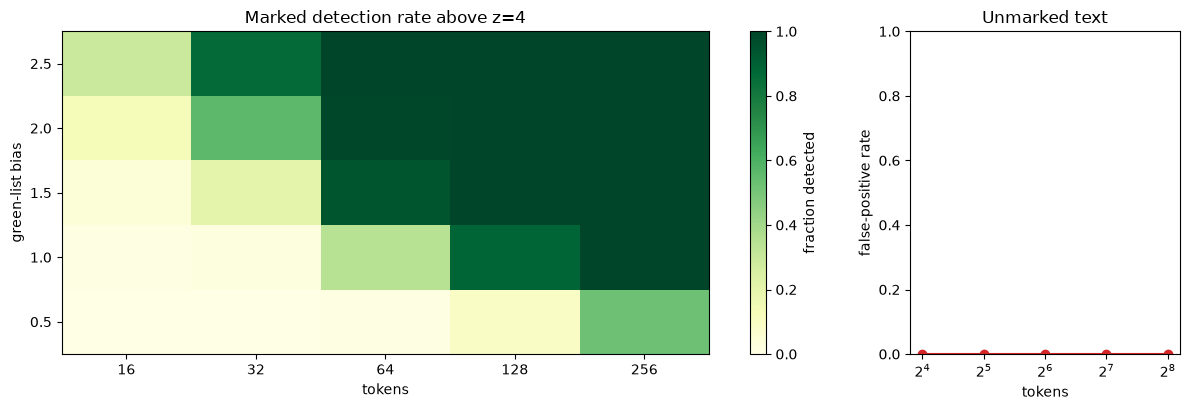

In [7]:
def detection_power(lengths=(16, 32, 64, 128, 256), biases=(0.5, 1.0, 1.5, 2.0, 2.5), threshold=4.0, trials=100):
    result = np.zeros((len(biases), len(lengths)))
    false_positive = np.zeros(len(lengths))
    for column, length in enumerate(lengths):
        clean_scores = [watermark_z_score(sample_tokens(length, 0.0, seed=2000 + trial)) for trial in range(trials)]
        false_positive[column] = np.mean(np.asarray(clean_scores) >= threshold)
        for row, bias in enumerate(biases):
            marked_scores = [watermark_z_score(sample_tokens(length, bias, seed=1000 + trial)) for trial in range(trials)]
            result[row, column] = np.mean(np.asarray(marked_scores) >= threshold)
    return result, false_positive

lengths = np.array([16, 32, 64, 128, 256])
biases = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
power, false_positive = detection_power(lengths, biases)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={'width_ratios': [3, 1]})
image = axes[0].imshow(power, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='YlGn')
axes[0].set_xticks(range(len(lengths)), lengths)
axes[0].set_yticks(range(len(biases)), [f'{bias:.1f}' for bias in biases])
axes[0].set_xlabel('tokens')
axes[0].set_ylabel('green-list bias')
axes[0].set_title('Marked detection rate above z=4')
figure.colorbar(image, ax=axes[0], label='fraction detected')
axes[1].plot(lengths, false_positive, marker='o', color='tab:red')
axes[1].set_xscale('log', base=2)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('tokens')
axes[1].set_ylabel('false-positive rate')
axes[1].set_title('Unmarked text')
plt.tight_layout()


## 7. See how paraphrase changes the evidence

A detector reconstructs keyed labels from token identities and positions; it does not score meaning directly. These two sentences communicate nearly the same idea, but the paraphrase replaces several tokens and changes the mapping that the detector observes.

This is why text watermark robustness differs from image compression robustness: a rewrite can preserve the reader's meaning while removing the generator's original sequence of choices.

In [8]:
original = ['the', 'model', 'generated', 'a', 'small', 'image']
paraphrase = ['the', 'system', 'created', 'a', 'tiny', 'picture']
for token in ['system', 'created', 'tiny', 'picture']:
    if token not in VOCABULARY_INDEX:
        VOCABULARY_INDEX[token] = len(VOCABULARY_INDEX)

def explain_sentence(tokens, key=KEY):
    print('{:<12} {:<12}'.format('Token', 'Keyed color'))
    print('-' * 24)
    for position, token in enumerate(tokens):
        if token not in VOCABULARY_INDEX or VOCABULARY_INDEX[token] >= len(VOCABULARY):
            print(f'{token:<12} unknown to toy vocabulary')
        else:
            color = 'green' if green_mask(position, key)[VOCABULARY_INDEX[token]] else 'red'
            print(f'{token:<12} {color:<12}')

print('Original:  ', ' '.join(original))
explain_sentence(original)
print()
print('Paraphrase:', ' '.join(paraphrase))
explain_sentence(paraphrase)


Original:   the model generated a small image
Token        Keyed color 
------------------------
the          red         
model        red         
generated    red         
a            red         
small        green       
image        red         

Paraphrase: the system created a tiny picture
Token        Keyed color 
------------------------
the          red         
system       unknown to toy vocabulary
created      unknown to toy vocabulary
a            red         
tiny         unknown to toy vocabulary
picture      unknown to toy vocabulary


## What to carry forward

- The important object is the position-and-key-to-token mapping, not a visible mark in the text.
- A stronger bias improves detectability but can reduce fluency or make the pattern easier to attack.
- Detection is hypothesis testing with a calibrated null distribution, not exact message recovery.
- A negative result is only “not detected by this key and detector on this rendition.” It is not proof of human authorship.